# Part II - Ford GoBike System Data
## by Belal Nwiran

## Investigation overview

**Goal.** Explain how trip timing, duration, rider membership, and station activity reveal two distinct use cases for Ford GoBike: routine commuting and more casual riding.

**Key questions.**

1. How dominant are Subscribers compared with Customers?
2. When do the two groups ride on weekdays and weekends?
3. How do their trip durations compare?
4. Do the busiest origin stations reinforce a commute-oriented story?

**Main findings.** Subscribers account for about 89% of trips, create sharp weekday commute peaks, and take shorter trips. Customers account for a smaller share, ride longer, and have a flatter daily pattern. Transit-adjacent stations dominate the busiest origins, which is consistent with last-mile commuting.

## Dataset overview

This presentation uses **183,220 cleaned trip records** from the Ford GoBike (now Bay Wheels) public trip-history data for **February 2019** in the San Francisco Bay Area. Each row is one ride and includes timing, duration, station, bike, membership type, and optional rider demographics.

The analysis converts timestamps to weekday/hour features, expresses duration in minutes, and excludes 192 implausible ages over 80. The long right tail of trip duration is retained and shown on a logarithmic scale where needed.

**Source:** [Bay Wheels System Data](https://www.lyft.com/bikes/bay-wheels/system-data); February 2019 Ford GoBike trip-data file supplied with the project.

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [23]:
rides_df = pd.read_csv("201902-fordgobike-tripdata-cleaned.csv", parse_dates=['start_time', 'end_time'])

In [24]:
blue, orange = '#2374AB', '#F28E2B'

rides_df['user_type'] = rides_df['user_type'].astype('category')
rides_df['start_dow'] = rides_df['start_dow'].astype('category')
print(f"Loaded {len(rides_df):,} cleaned trip records.")

Loaded 183,220 cleaned trip records.


## 1. Subscribers are the system's core users

Nearly nine out of every ten February trips were taken by **Subscribers**. This strong membership skew sets up the rest of the story: patterns that characterize overall trip volume will mostly reflect the habits of regular members.

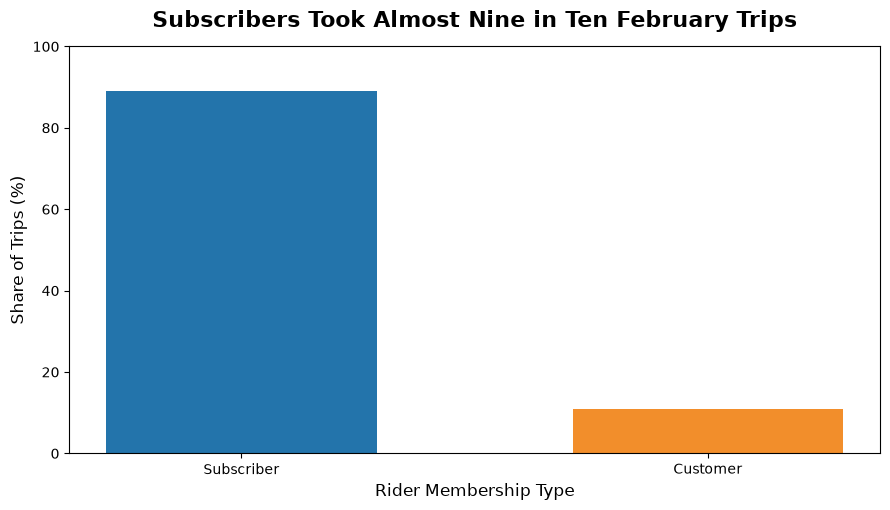

In [25]:
counts = rides_df['user_type'].value_counts().reindex(['Subscriber', 'Customer'])
shares = counts / counts.sum() * 100
fig, ax = plt.subplots(figsize=(9, 5.2))
bars = ax.bar(counts.index, shares, color=[blue, orange], width=0.58)

ax.set_title('Subscribers Took Almost Nine in Ten February Trips', fontsize=16, weight='bold', pad=14)
ax.set_xlabel('Rider Membership Type', fontsize=12)
ax.set_ylabel('Share of Trips (%)', fontsize=12)
ax.set_ylim(0, 100); 
ax.set_yticks(np.arange(0, 101, 20))

plt.tight_layout(); 
plt.show()

## 2. The weekday commute signature belongs to Subscribers

Subscriber rides form pronounced peaks around **8 AM** and **5–6 PM** on weekdays; both peaks disappear on weekends. Customer activity is much lower and comparatively even across the day. This split is the clearest evidence of routine commuting by Subscribers rather than a system-wide pattern.

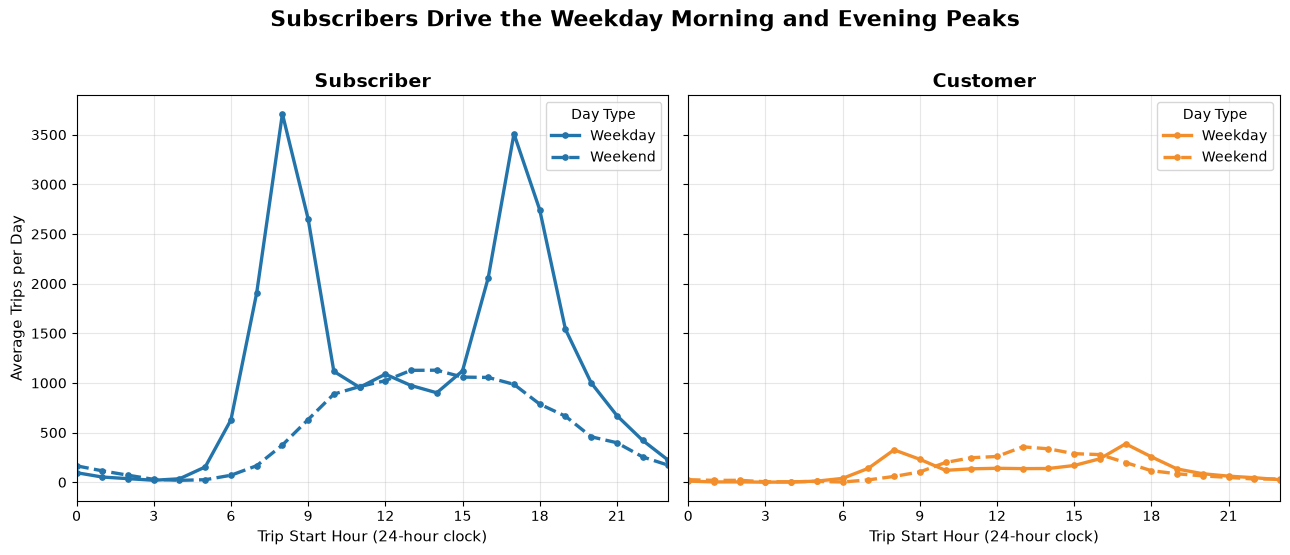

In [26]:
hourly = (rides_df.groupby(['user_type', 'is_weekend', 'start_hour'], observed=True).size()
          .rename('trips').reset_index())
fig, axes = plt.subplots(1, 2, figsize=(13, 5.4), sharey=True)
for ax, user_type, color in zip(axes, ['Subscriber', 'Customer'], ['#2374AB', '#F28E2B']):
    subset = hourly[hourly['user_type'] == user_type]
    for period, line_style, divisor in [('Weekday', '-', 5), ('Weekend', '--', 2)]:
        line = subset[subset['is_weekend'] == period]
        ax.plot(line['start_hour'], line['trips'] / divisor, color=color, linestyle=line_style,
                marker='o', markersize=3.8, linewidth=2.4, label=period)
    ax.set_title(user_type, fontsize=14, weight='bold')
    ax.set_xlabel('Trip Start Hour (24-hour clock)', fontsize=11)
    ax.set_xlim(0, 23); ax.set_xticks(np.arange(0, 24, 3))
    ax.legend(title='Day Type', frameon=True); ax.grid(alpha=0.3)
axes[0].set_ylabel('Average Trips per Day', fontsize=11)
fig.suptitle('Subscribers Drive the Weekday Morning and Evening Peaks', fontsize=16, weight='bold', y=1.02)
plt.tight_layout(); plt.show()

## 3. Customers ride longer, even after accounting for extreme trips

The median Customer trip is roughly **13.2 minutes**, versus **8.2 minutes** for Subscribers. A logarithmic duration axis preserves the full distribution without letting a small number of unusually long rides obscure the typical trip. The consistently higher Customer distribution supports a more casual or leisure-oriented use case.

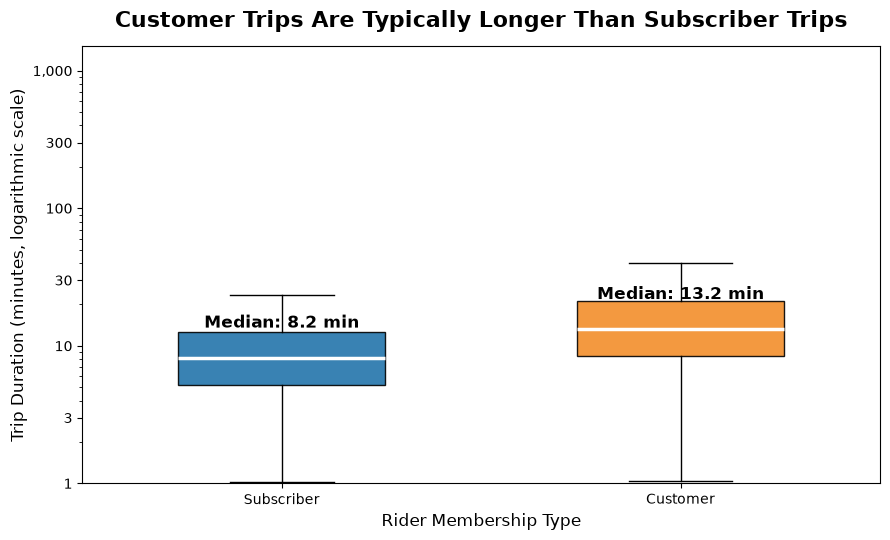

In [27]:
duration_order = ['Subscriber', 'Customer']
duration_data = [rides_df.loc[rides_df['user_type'] == group, 'duration_min'].dropna() for group in duration_order]
medians = [series.median() for series in duration_data]
fig, ax = plt.subplots(figsize=(9, 5.5))
box = ax.boxplot(duration_data, tick_labels=duration_order, patch_artist=True, showfliers=False,
                 widths=0.52, medianprops={'color': 'white', 'linewidth': 2.5})
for patch, color in zip(box['boxes'], [blue, orange]):
    patch.set_facecolor(color); patch.set_alpha(0.9)

ax.set_yscale('log'); ax.set_ylim(1, 1500)
ax.set_yticks([1, 3, 10, 30, 100, 300, 1000])
ax.set_yticklabels(['1', '3', '10', '30', '100', '300', '1,000'])
ax.set_title('Customer Trips Are Typically Longer Than Subscriber Trips', fontsize=16, weight='bold', pad=14)
ax.set_xlabel('Rider Membership Type', fontsize=12)
ax.set_ylabel('Trip Duration (minutes, logarithmic scale)', fontsize=12)

for x, median in enumerate(medians, start=1):
    ax.text(x, median * 1.55, f'Median: {median:.1f} min', ha='center', va='bottom', fontsize=12, weight='bold')

plt.tight_layout(); 
plt.show()

## 4. The busiest starts cluster at regional transit hubs

Several of the highest-volume origin stations are at or next to **Caltrain, BART, and the Ferry Building**. Station names alone cannot prove trip purpose, but together with the subscriber-heavy weekday peaks they provide converging evidence that the system often serves last-mile transit connections.

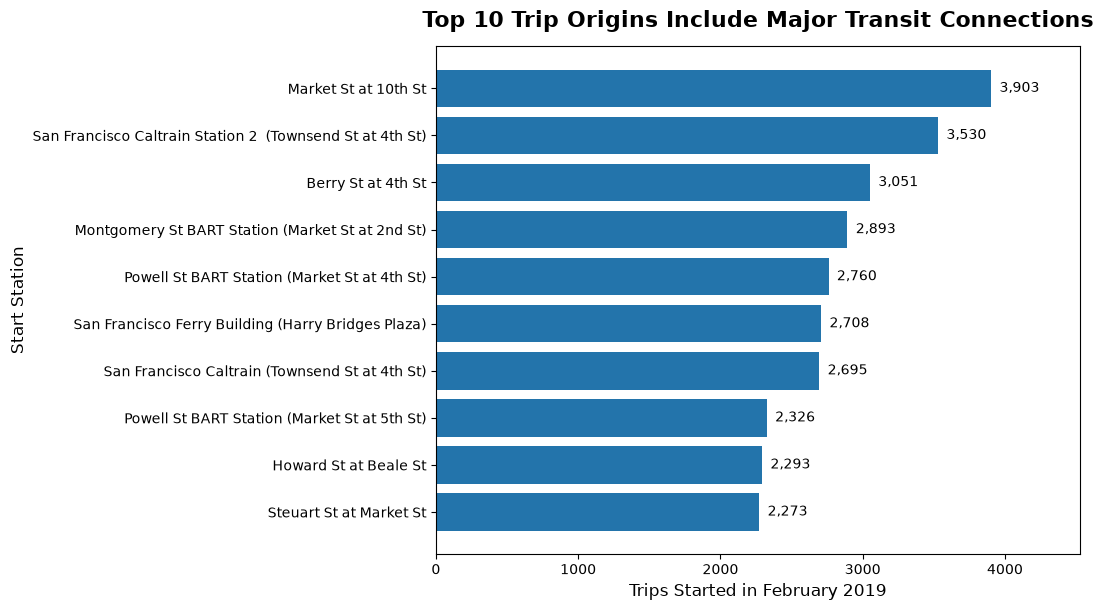

In [28]:
top = rides_df['start_station_name'].value_counts().head(10).sort_values()
fig, ax = plt.subplots(figsize=(11, 6.2))
bars = ax.barh(top.index, top.values, color=blue)
ax.set_title('Top 10 Trip Origins Include Major Transit Connections', fontsize=16, weight='bold', pad=14)
ax.set_xlabel('Trips Started in February 2019', fontsize=12)
ax.set_ylabel('Start Station', fontsize=12)
ax.set_xlim(0, top.max() * 1.16)

for bar, value in zip(bars, top.values):
    ax.text(value + top.max() * 0.015, bar.get_y() + bar.get_height()/2, f'{value:,}', va='center', fontsize=10)
plt.tight_layout(); plt.show()

## Conclusions

Ford GoBike's February 2019 activity tells a consistent two-segment story:

- **Subscribers (89%)** are the core market: short trips and sharp weekday commute peaks.
- **Customers (11%)** ride for longer and follow a flatter daily pattern.
- The leading origin stations near Caltrain, BART, and the Ferry Building reinforce a likely **last-mile transit** role.

These are observational patterns, not direct measures of trip purpose. Still, membership, timing, duration, and station location all point in the same direction: Ford GoBike was primarily a commuting service with a smaller casual-riding segment.